In [25]:
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
# retrieves results where the uptake rate is either 20 or 12044
# volume is 1 or 548 
# discretiation varies fro 2,10,20

In [27]:
# conditions we want to plot
conditions = [
    # {"uptake": 12044, "volume": 523.6, "dx": None}
    # , 
    {"uptake": 12044, "volume": 1, "dx": None}
    # ,     
    # {"uptake": 20, "volume": 1, "dx": None}  
]


In [28]:
# folder where results are mounted
turbine_folder = "/home/tntiniak/Work/mnt/"
instance_dirs = glob.glob(f"{turbine_folder}/instance_*")
all_data = []


In [29]:
for directory in instance_dirs:
    xml_data = directory+"/output/settings.xml"
    directory
    tree = ET.parse(xml_data)
    root = tree.getroot()
    # root = ET.fromstring(xml_data)
    dx = root.find("./domain/dx").text
    uptake = root.find("./cell_definitions/cell_definition/phenotype/secretion/substrate/uptake_rate").text
    volume = root.find("./cell_definitions/cell_definition/phenotype/volume/total").text
    mean_df = pd.read_csv(directory+"/microenv_many_diffusion.csv",header=0)
    mean_df['diff']/=602.2


    # Add a unique label for each experiment
    mean_df["label"] = f"dx={dx}, uptake={uptake}, vol={volume}"
    mean_df["dx"] = float(dx)
    mean_df["uptake"] = float(uptake)
    mean_df["volume"] = float(volume)
    
    all_data.append(mean_df)

In [30]:
combined_df = pd.concat(all_data, ignore_index=True)


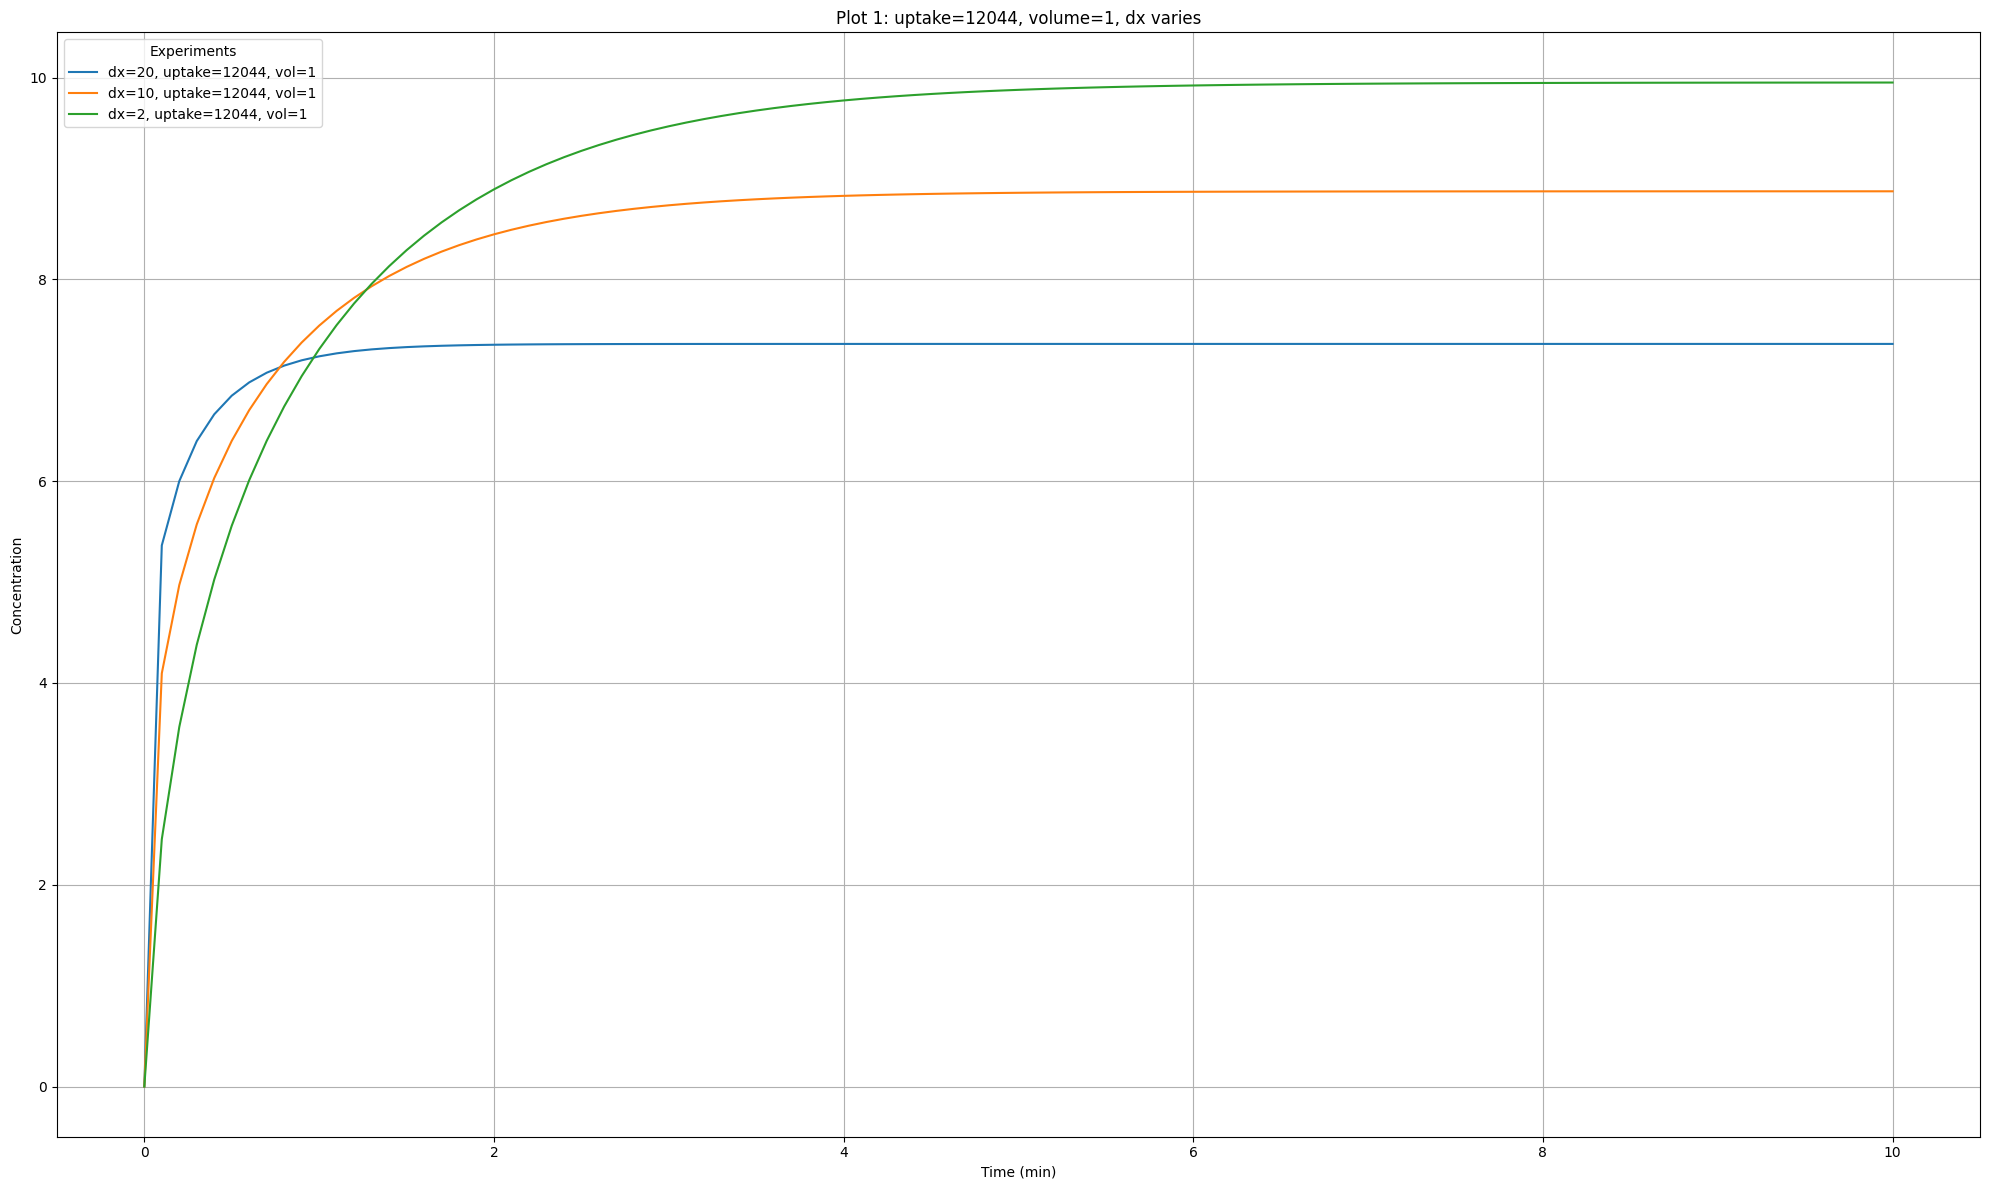

Saved plot to /home/tntiniak/Work/github/Benchmarks/observatory_benchmark/multiscale_benchmark/2022_09_hackathon/Physicell/analysis/Diffusion_1kCells/plots/plot_1_uptake_12044_volume_1_dx_None.png


In [31]:
for i, condition in enumerate(conditions, start=1):
    # Filter data based on condition
    filtered_df = combined_df.copy()
    # print(filtered_df)
    if condition["uptake"] is not None:
        filtered_df = filtered_df[filtered_df["uptake"] == condition["uptake"]]
    if condition["volume"] is not None:
        filtered_df = filtered_df[filtered_df["volume"] == condition["volume"]]
    if condition["dx"] is not None:
        filtered_df = filtered_df[filtered_df["dx"] == condition["dx"]]
    # Create the plot
    plt.figure(figsize=(20, 12))
    sns.lineplot(
        data=filtered_df,
        x="dt",
        y="diff",
        hue="label",
        palette="tab10"  # Adjust palette if needed
    )

    # Customize plot
    title = f"Plot {i}: "
    title += f"uptake={condition['uptake']}" if condition["uptake"] is not None else "uptake varies"
    title += f", volume={condition['volume']}" if condition["volume"] is not None else ", volume varies"
    title += f", dx={condition['dx']}" if condition["dx"] is not None else ", dx varies"
    plt.title(title)
    plt.xlabel("Time (min)")
    plt.ylabel("Concentration")
    plt.legend(title="Experiments")
    plt.grid(True)
    plt.tight_layout()
    
    # # Save plot
    plot_filename = f"/home/tntiniak/Work/github/Benchmarks/observatory_benchmark/multiscale_benchmark/2022_09_hackathon/Physicell/analysis/Diffusion_1kCells/plots/plot_{i}_uptake_{condition['uptake']}_volume_{condition['volume']}_dx_{condition['dx']}.png"
    # plt.savefig(plot_filename, dpi=300)
    plt.show()
    print(f"Saved plot to {plot_filename}")

/tmp/ipykernel_11410/691988250.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


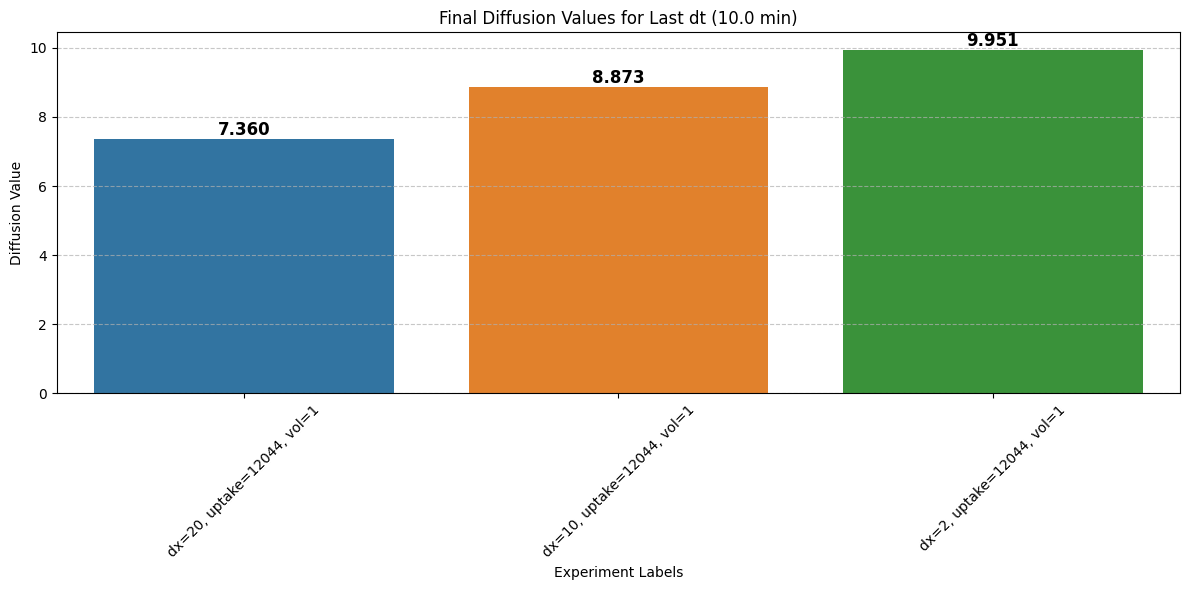

Saved bar plot to /home/tntiniak/Work/github/Benchmarks/observatory_benchmark/multiscale_benchmark/2022_09_hackathon/Physicell/analysis/Diffusion_1kCells/plots/barplot_1_uptake_12044_volume_1_dx_None.png


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

for i, condition in enumerate(conditions, start=1):
    # Filter data based on condition
    filtered_df = combined_df.copy()
    
    if condition["uptake"] is not None:
        filtered_df = filtered_df[filtered_df["uptake"] == condition["uptake"]]
    if condition["volume"] is not None:
        filtered_df = filtered_df[filtered_df["volume"] == condition["volume"]]
    if condition["dx"] is not None:
        filtered_df = filtered_df[filtered_df["dx"] == condition["dx"]]

    # Find the last dt value
    last_dt = filtered_df["dt"].max()
    
    # Extract last diffusion values for each label
    last_values = filtered_df[filtered_df["dt"] == last_dt]

    # Create a bar plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=last_values,
        x="label",
        y="diff",
        palette="tab10"
    )

    # Annotate bars with values rounded to 3 decimal places
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",  # Format to 3 decimals
            (p.get_x() + p.get_width() / 2, p.get_height()),  # Position at the top of the bar
            ha="center", va="bottom", fontsize=12, fontweight="bold", color="black"
        )

    # Customize plot
    title = f"Final Diffusion Values for Last dt ({last_dt} min)"
    plt.title(title)
    plt.xlabel("Experiment Labels")
    plt.ylabel("Diffusion Value")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    # Save bar plot
    barplot_filename = f"/home/tntiniak/Work/github/Benchmarks/observatory_benchmark/multiscale_benchmark/2022_09_hackathon/Physicell/analysis/Diffusion_1kCells/plots/barplot_{i}_uptake_{condition['uptake']}_volume_{condition['volume']}_dx_{condition['dx']}.png"
    # plt.savefig(barplot_filename, dpi=300)
    plt.show()
    print(f"Saved bar plot to {barplot_filename}")